# SEPTA Transit Accessibility Analysis Using PySpark

**Course:** DSCI 632 - Applied Cloud Computing  
**Team:** Priti Sagar, Het Patel, Leili Massoum Zadeh

This notebook analyzes public transit accessibility across 159 Philadelphia neighborhoods using SEPTA GTFS data. We calculate accessibility scores and build machine learning models to identify underserved areas ("transit deserts").

---

## Part 1: Environment Setup and Data Acquisition

### Install Required Packages
Install PySpark for distributed data processing and geospatial libraries (GeoPandas, Shapely, Folium) for mapping and spatial analysis.

In [ ]:
# Install required packages
!pip install pyspark==3.5.0
!pip install geopandas shapely folium
!pip install pyproj

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 26.7 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425346 sha256=cca8c1bba920a330f1dbf6ed9602877e47eef730bb76e2b80a8c1e9658de5660
  Stored in directory: /root/.cache/pip/wheels/84/40/20/65eefe766118e0a8f8e385cc3ed6e9eb7241c7e51cfc04c51a
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.2
    Uninstalling pyspark-4.0.2:
      Successfully uninstalled pyspark-4.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-conn

### Download SEPTA GTFS Data
Download the official SEPTA GTFS (General Transit Feed Specification) data containing bus and rail schedules, stop locations, routes, and trip information. The data is extracted into separate bus and rail folders.

In [ ]:
# Download SEPTA GTFS data directly to Colab
import requests
import zipfile
import os

# Create directories
os.makedirs('septa_gtfs/bus', exist_ok=True)
os.makedirs('septa_gtfs/rail', exist_ok=True)

# Download GTFS data
print("Downloading SEPTA GTFS data...")
url = "https://www3.septa.org/developer/gtfs_public.zip"
response = requests.get(url)

with open('septa_gtfs.zip', 'wb') as f:
    f.write(response.content)

# Extract main zip
with zipfile.ZipFile('septa_gtfs.zip', 'r') as z:
    z.extractall('septa_gtfs/')

# Extract nested zips
with zipfile.ZipFile('septa_gtfs/google_bus.zip', 'r') as z:
    z.extractall('septa_gtfs/bus/')

with zipfile.ZipFile('septa_gtfs/google_rail.zip', 'r') as z:
    z.extractall('septa_gtfs/rail/')

print("Download complete!")
print("Bus files:", os.listdir('septa_gtfs/bus/'))
print("Rail files:", os.listdir('septa_gtfs/rail/'))

Download complete!
Bus files: ['route_stops.txt', 'fare_leg_rules.txt', 'routes.txt', 'stops.txt', 'stop_times.txt', 'shapes.txt', 'feed_info.txt', 'directions.txt', 'calendar.txt', 'trips.txt', 'fare_products.txt', 'fare_transfer_rules.txt', 'fare_media.txt', 'rider_categories.txt', 'agency.txt', 'calendar_dates.txt']
Rail files: ['route_stops.txt', 'routes.txt', 'stops.txt', 'stop_times.txt', 'shapes.txt', 'feed_info.txt', 'directions.txt', 'calendar.txt', 'trips.txt', 'agency.txt', 'calendar_dates.txt']


### Download Philadelphia Neighborhoods Data
Download GeoJSON file containing boundary polygons for 159 Philadelphia neighborhoods from OpenDataPhilly. This will be used to calculate accessibility scores per neighborhood.

In [ ]:
# Download Philadelphia neighborhoods boundary data
# Using alternative source since original URL is unavailable
import urllib.request

# Tried multiple sources
urls_to_try = [
    "https://raw.githubusercontent.com/opendataphilly/open-geo-data/master/philadelphia-neighborhoods/philadelphia-neighborhoods.geojson",
    "https://raw.githubusercontent.com/blackmad/neighborhoods/master/philadelphia.geojson"
]

downloaded = False
for url in urls_to_try:
    try:
        print(f"Trying: {url}")
        urllib.request.urlretrieve(url, 'philadelphia_neighborhoods.geojson')
        print("Neighborhoods data downloaded successfully!")
        downloaded = True
        break
    except Exception as e:
        print(f"Failed: {e}")
        continue

# backup method
if not downloaded:
    print("\nDirect download failed. Using geopandas to fetch from OpenDataPhilly...")
    import geopandas as gpd

    # OpenDataPhilly direct API endpoint
    neighborhoods_gdf = gpd.read_file(
        "https://opendata.arcgis.com/api/v3/datasets/b9e0c8a8e5e84f8a9e8c8a8e5e84f8a9/downloads/data?format=geojson&spatialRefId=4326"
    )
    neighborhoods_gdf.to_file('philadelphia_neighborhoods.geojson', driver='GeoJSON')
    print("Downloaded via GeoDataFrame!")

Trying: https://raw.githubusercontent.com/opendataphilly/open-geo-data/master/philadelphia-neighborhoods/philadelphia-neighborhoods.geojson
Neighborhoods data downloaded successfully!


---

## Part 2: Initialize PySpark and Load Data

### Initialize PySpark Session
Create a Spark session with 4GB driver memory for distributed data processing. This enables us to efficiently handle millions of transit records.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window
import math

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("SEPTA Transit Accessibility Analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")
print("Spark Session initialized successfully!")

Spark Version: 3.5.0
Spark Session initialized successfully!


### Load GTFS Data into PySpark DataFrames
Load all GTFS CSV files (stops, stop_times, trips, routes) for both bus and rail into Spark DataFrames. The stop_times file contains over 2.7 million rows of arrival/departure data.

In [ ]:
# Load Bus GTFS data
bus_stops = spark.read.csv('septa_gtfs/bus/stops.txt', header=True, inferSchema=True)
bus_stop_times = spark.read.csv('septa_gtfs/bus/stop_times.txt', header=True, inferSchema=True)
bus_trips = spark.read.csv('septa_gtfs/bus/trips.txt', header=True, inferSchema=True)
bus_routes = spark.read.csv('septa_gtfs/bus/routes.txt', header=True, inferSchema=True)
bus_calendar = spark.read.csv('septa_gtfs/bus/calendar.txt', header=True, inferSchema=True)

# Load Rail GTFS data
rail_stops = spark.read.csv('septa_gtfs/rail/stops.txt', header=True, inferSchema=True)
rail_stop_times = spark.read.csv('septa_gtfs/rail/stop_times.txt', header=True, inferSchema=True)
rail_trips = spark.read.csv('septa_gtfs/rail/trips.txt', header=True, inferSchema=True)
rail_routes = spark.read.csv('septa_gtfs/rail/routes.txt', header=True, inferSchema=True)

# Print data row counts
print("=== Dataset Sizes ===")
print(f"Bus Stops: {bus_stops.count():,} rows")
print(f"Bus Stop Times: {bus_stop_times.count():,} rows")
print(f"Bus Trips: {bus_trips.count():,} rows")
print(f"Bus Routes: {bus_routes.count():,} rows")
print(f"Rail Stops: {rail_stops.count():,} rows")
print(f"Rail Stop Times: {rail_stop_times.count():,} rows")

=== Dataset Sizes ===
Bus Stops: 13,771 rows
Bus Stop Times: 2,043,740 rows
Bus Trips: 35,080 rows
Bus Routes: 172 rows
Rail Stops: 156 rows
Rail Stop Times: 17,114 rows


---

## Part 3: Exploratory Data Analysis (EDA)

### Explore Data Structure
Display sample records from bus stops, stop times, and routes to understand the data structure and available fields.

In [ ]:
# Show sample data
print("=== Bus Stops Sample ===")
bus_stops.select("stop_id", "stop_name", "stop_lat", "stop_lon").show(5, truncate=False)

print("\n=== Bus Stop Times Sample ===")
bus_stop_times.select("trip_id", "arrival_time", "departure_time", "stop_id").show(5)

print("\n=== Bus Routes Sample ===")
bus_routes.select("route_id", "route_short_name", "route_long_name").show(10, truncate=False)

print("\n=== Schema ===")
bus_stops.printSchema()

=== Bus Stops Sample ===
+-------+--------------------------------+---------+----------+
|stop_id|stop_name                       |stop_lat |stop_lon  |
+-------+--------------------------------+---------+----------+
|4      |Roosevelt Blvd & Broad St - FS  |40.018128|-75.148887|
|5      |Roosevelt Blvd & 5th St         |40.023465|-75.133487|
|7      |Roosevelt Blvd & Pratt St       |40.028754|-75.089524|
|8      |Roosevelt Blvd & Cottman Av - FS|40.04461 |-75.053657|
|9      |Roosevelt Blvd & Holme Av       |40.058496|-75.044312|
+-------+--------------------------------+---------+----------+
only showing top 5 rows


=== Bus Stop Times Sample ===
+-------+------------+--------------+-------+
|trip_id|arrival_time|departure_time|stop_id|
+-------+------------+--------------+-------+
| 656953|    06:05:00|      06:05:00|    809|
| 656953|    06:05:36|      06:05:36|  27684|
| 656953|    06:07:20|      06:07:20|   2321|
| 656953|    06:08:18|      06:08:18|  16404|
| 656953|    06:09:26

### Combine Bus and Rail Stops
Merge bus stops (13,699) and rail stations (156) into a single DataFrame with a transit_type column to distinguish between them. Total: 13,855 transit stops.

In [ ]:
# Add transit type column and combine bus and rail stops
bus_stops_typed = bus_stops.withColumn("transit_type", lit("bus"))
rail_stops_typed = rail_stops.withColumn("transit_type", lit("rail"))

# Select common columns and union
common_cols = ["stop_id", "stop_name", "stop_lat", "stop_lon", "transit_type"]

all_stops = bus_stops_typed.select(
    col("stop_id").cast("string"),
    "stop_name",
    col("stop_lat").cast("double"),
    col("stop_lon").cast("double"),
    "transit_type"
).union(
    rail_stops_typed.select(
        col("stop_id").cast("string"),
        "stop_name",
        col("stop_lat").cast("double"),
        col("stop_lon").cast("double"),
        "transit_type"
    )
)

print(f"Total combined stops: {all_stops.count():,}")
all_stops.groupBy("transit_type").count().show()

Total combined stops: 13,927
+------------+-----+
|transit_type|count|
+------------+-----+
|         bus|13771|
|        rail|  156|
+------------+-----+



### Load Neighborhood Boundaries
Load the Philadelphia neighborhoods GeoJSON file using GeoPandas to access the 159 neighborhood polygons and their properties.

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Load neighborhoods
neighborhoods_gdf = gpd.read_file('philadelphia_neighborhoods.geojson')
print(f"Number of neighborhoods: {len(neighborhoods_gdf)}")
print(f"Columns: {neighborhoods_gdf.columns.tolist()}")
neighborhoods_gdf.head()

Number of neighborhoods: 159
Columns: ['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area', 'geometry']


,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((-75.06773 40.0054, -75.06765 4..."
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((-75.0156 40.09487, -75.01768 4..."
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((-75.18848 40.07273, -75.18846 ..."
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((-75.21221 40.08604, -75.2121 4..."
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((-75.18476 40.02829, -75.18426 ..."


### Check Neighborhood Column Names
Inspect the available columns in the GeoJSON to identify the correct field name for neighborhood names.

In [ ]:
# Check available columns first
print("Available columns:", neighborhoods_gdf.columns.tolist())
print("\nSample data:")
print(neighborhoods_gdf.head(2))

Available columns: ['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area', 'geometry']

Sample data:
         NAME    LISTNAME     MAPNAME    Shape_Leng    Shape_Area  \
0  BRIDESBURG  Bridesburg  Bridesburg  27814.546521  4.458626e+07   
1   BUSTLETON   Bustleton   Bustleton  48868.458365  1.140504e+08   

                                            geometry  
0  MULTIPOLYGON (((-75.06773 40.0054, -75.06765 4...  
1  MULTIPOLYGON (((-75.0156 40.09487, -75.01768 4...  


### Calculate Neighborhood Centroids
Project neighborhoods to Pennsylvania State Plane coordinate system for accurate centroid calculation, then convert back to lat/lon. Create a Spark DataFrame with neighborhood names and centroid coordinates.

In [ ]:
# Project to a local CRS (Pennsylvania State Plane) for accurate centroid calculation
neighborhoods_projected = neighborhoods_gdf.to_crs(epsg=2272)  # PA State Plan South

# Calculate centroid in projected coordinates
neighborhoods_projected['centroid'] = neighborhoods_projected.geometry.centroid

# Convert centroid back to latitude/longitude (WGS84)
neighborhoods_projected['centroid_wgs84'] = neighborhoods_projected['centroid'].to_crs(epsg=4326)
neighborhoods_gdf['centroid_lat'] = neighborhoods_projected['centroid_wgs84'].y
neighborhoods_gdf['centroid_lon'] = neighborhoods_projected['centroid_wgs84'].x

# Find the correct column name for neighborhood name
# Common names: 'name', 'NAME', 'MAPNAME', 'mapname', 'neighborhood', 'listname'
name_col = None
for col in ['name', 'NAME', 'MAPNAME', 'mapname', 'neighborhood', 'listname', 'LISTNAME']:
    if col in neighborhoods_gdf.columns:
        name_col = col
        break

if name_col is None:
    print("Available columns:", neighborhoods_gdf.columns.tolist())
    raise ValueError("Could not find neighborhood name column!")

print(f"Using column '{name_col}' for neighborhood names")

# Create a clean dataframe for Spark
neighborhoods_pd = neighborhoods_gdf[[name_col, 'centroid_lat', 'centroid_lon']].copy()
neighborhoods_pd.columns = ['neighborhood_name', 'centroid_lat', 'centroid_lon']

# Convert to Spark DataFrame
neighborhoods_spark = spark.createDataFrame(neighborhoods_pd)
neighborhoods_spark.show(10, truncate=False)
print(f"Total neighborhoods: {neighborhoods_spark.count()}")

Using column 'NAME' for neighborhood names
+-----------------+------------------+------------------+
|neighborhood_name|centroid_lat      |centroid_lon      |
+-----------------+------------------+------------------+
|BRIDESBURG       |39.99728074052621 |-75.06936336406197|
|BUSTLETON        |40.093392756402274|-75.04222853746037|
|CEDARBROOK       |40.07493561490369 |-75.1759604895934 |
|CHESTNUT_HILL    |40.07155785525776 |-75.2105707633146 |
|EAST_FALLS       |40.01741050913476 |-75.18987989423267|
|MOUNT_AIRY_EAST  |40.059456908122854|-75.18112450319208|
|GRAYS_FERRY      |39.93374538834559 |-75.19449653880531|
|OLNEY            |40.034463332762186|-75.12565247430155|
|PENNYPACK_PARK   |40.06978457783708 |-75.0488911242964 |
|SOMERTON         |40.1164447236957  |-75.01688681265446|
+-----------------+------------------+------------------+
only showing top 10 rows

Total neighborhoods: 159


---

## Part 4: Feature Engineering

### Define Haversine Distance Function
Create a PySpark User Defined Function (UDF) to calculate the distance in kilometers between two geographic points using the Haversine formula.

In [ ]:
# Haversine formula to calculate distance between two latitude/longitude points
@udf(returnType=DoubleType())
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in kilometers between two points"""
    if lat1 is None or lon1 is None or lat2 is None or lon2 is None:
        return None

    R = 6371  # Earth's radius in kilometers

    lat1_rad = math.radians(lat1)
    lat2_rad = math.radians(lat2)
    delta_lat = math.radians(lat2 - lat1)
    delta_lon = math.radians(lon2 - lon1)

    a = math.sin(delta_lat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(delta_lon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    return R * c

print("Haversine UDF registered!")

Haversine UDF registered!


### Cross Join - Calculate Distances
Perform a cross join between neighborhoods and transit stops to calculate the distance from each neighborhood centroid to every transit stop. This creates ~2.2 million distance records.

In [ ]:
# Re-import col to fix the override issue
from pyspark.sql.functions import col, lit, count, when, min, max, avg, sum, desc, lag, countDistinct

# Cross join to calculate distance from each neighborhood to each stop(This creates the large dataset for analysis)


neighborhood_stop_distances = neighborhoods_spark.crossJoin(all_stops)

# Calculate distance from each neighborhood centroid to each stop
neighborhood_stop_distances = neighborhood_stop_distances.withColumn(
    "distance_km",
    haversine_distance(
        col("centroid_lat"), col("centroid_lon"),
        col("stop_lat"), col("stop_lon")
    )
)

print(f"Total rows (neighborhoods x stops): {neighborhood_stop_distances.count():,}")
neighborhood_stop_distances.show(5)

Total rows (neighborhoods x stops): 2,214,393
+-----------------+-----------------+------------------+-------+--------------------+---------+----------+------------+------------------+
|neighborhood_name|     centroid_lat|      centroid_lon|stop_id|           stop_name| stop_lat|  stop_lon|transit_type|       distance_km|
+-----------------+-----------------+------------------+-------+--------------------+---------+----------+------------+------------------+
|       BRIDESBURG|39.99728074052621|-75.06936336406197|      4|Roosevelt Blvd & ...|40.018128|-75.148887|         bus|7.1587869022819435|
|       BRIDESBURG|39.99728074052621|-75.06936336406197|      5|Roosevelt Blvd & ...|40.023465|-75.133487|         bus| 6.188883515761669|
|       BRIDESBURG|39.99728074052621|-75.06936336406197|      7|Roosevelt Blvd & ...|40.028754|-75.089524|         bus| 3.898156146917411|
|       BRIDESBURG|39.99728074052621|-75.06936336406197|      8|Roosevelt Blvd & ...| 40.04461|-75.053657|         bus|5

### Calculate Stop Density Features
For each neighborhood, count the total number of transit stops (bus + rail combined) within 500m, 1km, and 1.5km distance thresholds from the neighborhood centroid. Also calculate minimum distance to nearest stop and separate counts for bus vs rail stops.

In [ ]:
# Calculate number of stops within various distance thresholds for each neighborhood

# Stops within 500m, 1km, 1.5km
stops_within_thresholds = neighborhood_stop_distances.groupBy("neighborhood_name", "centroid_lat", "centroid_lon").agg(
    # Count stops within thresholds
    count(when(col("distance_km") <= 0.5, 1)).alias("stops_within_500m"),
    count(when(col("distance_km") <= 1.0, 1)).alias("stops_within_1km"),
    count(when(col("distance_km") <= 1.5, 1)).alias("stops_within_1500m"),

    # Minimum distance to any stop
    min("distance_km").alias("min_distance_to_stop_km"),

    # Average distance to nearest 5 stops
    avg("distance_km").alias("avg_distance_km"),

    # Count by transit type within 1km
    count(when((col("distance_km") <= 1.0) & (col("transit_type") == "bus"), 1)).alias("bus_stops_within_1km"),
    count(when((col("distance_km") <= 1.0) & (col("transit_type") == "rail"), 1)).alias("rail_stops_within_1km")
)

print("=== Stops Within Distance Thresholds ===")
stops_within_thresholds.orderBy(desc("stops_within_1km")).show(10, truncate=False)

=== Stops Within Distance Thresholds ===
+-----------------+------------------+------------------+-----------------+----------------+------------------+-----------------------+------------------+--------------------+---------------------+
|neighborhood_name|centroid_lat      |centroid_lon      |stops_within_500m|stops_within_1km|stops_within_1500m|min_distance_to_stop_km|avg_distance_km   |bus_stops_within_1km|rail_stops_within_1km|
+-----------------+------------------+------------------+-----------------+----------------+------------------+-----------------------+------------------+--------------------+---------------------+
|WASHINGTON_SQUARE|39.94734646008536 |-75.15954466598524|65               |253             |492               |0.024307014692740814   |14.71580812478726 |252                 |1                    |
|RITTENHOUSE      |39.94917645001766 |-75.17277245909301|56               |229             |453               |0.030624990691515714   |14.435360285047512|228          

### Calculate Route Diversity
Join stop_times with trips to determine which routes serve each stop. Count the number of unique routes within 1km of each neighborhood to measure route diversity.

In [ ]:
# Join stop_times with trips to get route information per stop
bus_stop_routes = bus_stop_times.join(bus_trips, "trip_id") \
    .select("stop_id", "route_id") \
    .distinct()

# Convert stop_id to string for joining
bus_stop_routes = bus_stop_routes.withColumn("stop_id", col("stop_id").cast("string"))

# Join with neighborhood-stop distances to get routes per neighborhood
neighborhood_routes = neighborhood_stop_distances \
    .filter(col("distance_km") <= 1.0) \
    .join(bus_stop_routes, "stop_id") \
    .groupBy("neighborhood_name") \
    .agg(
        countDistinct("route_id").alias("unique_routes_within_1km")
    )

print("=== Route Diversity by Neighborhood ===")
neighborhood_routes.orderBy(desc("unique_routes_within_1km")).show(10, truncate=False)

=== Route Diversity by Neighborhood ===
+-----------------+------------------------+
|neighborhood_name|unique_routes_within_1km|
+-----------------+------------------------+
|CHINATOWN        |42                      |
|CENTER_CITY      |40                      |
|WASHINGTON_SQUARE|39                      |
|CALLOWHILL       |37                      |
|LOGAN_SQUARE     |36                      |
|RITTENHOUSE      |34                      |
|FITLER_SQUARE    |26                      |
|OLD_CITY         |24                      |
|POWELTON         |23                      |
|SOCIETY_HILL     |23                      |
+-----------------+------------------------+
only showing top 10 rows



### Calculate Service Frequency
Count total daily trips and average trips per stop within 1km of each neighborhood to measure transit service frequency.

In [ ]:
# Parse arrival time and calculate trips per stop(for Counting total daily trips per stop)

trips_per_stop = bus_stop_times.groupBy("stop_id").agg(
    count("*").alias("total_trips")
)

# Get average trips per stop within each neighborhood
trips_per_stop = trips_per_stop.withColumn("stop_id", col("stop_id").cast("string"))

neighborhood_frequency = neighborhood_stop_distances \
    .filter(col("distance_km") <= 1.0) \
    .join(trips_per_stop, "stop_id") \
    .groupBy("neighborhood_name") \
    .agg(
        sum("total_trips").alias("total_trips_within_1km"),
        avg("total_trips").alias("avg_trips_per_stop")
    )

print("=== Transit Frequency by Neighborhood ===")
neighborhood_frequency.orderBy(desc("total_trips_within_1km")).show(10, truncate=False)

=== Transit Frequency by Neighborhood ===
+-----------------+----------------------+------------------+
|neighborhood_name|total_trips_within_1km|avg_trips_per_stop|
+-----------------+----------------------+------------------+
|CENTER_CITY      |86748                 |394.3090909090909 |
|WASHINGTON_SQUARE|85749                 |340.2738095238095 |
|RITTENHOUSE      |79296                 |347.7894736842105 |
|CHINATOWN        |76619                 |370.14009661835746|
|LOGAN_SQUARE     |66334                 |338.4387755102041 |
|OLD_CITY         |51343                 |324.95569620253167|
|CALLOWHILL       |50084                 |294.61176470588236|
|SOCIETY_HILL     |49194                 |265.9135135135135 |
|FITLER_SQUARE    |44768                 |285.14649681528664|
|UNIVERSITY_CITY  |44232                 |337.64885496183206|
+-----------------+----------------------+------------------+
only showing top 10 rows



### Calculate Distance to Center City
Calculate the distance from each neighborhood centroid to Philadelphia City Hall (downtown) as a measure of proximity to the urban core.

In [ ]:
# Center City Philadelphia coordinates (City Hall)
CENTER_CITY_LAT = 39.9526
CENTER_CITY_LON = -75.1652

# Add distance to center city for each neighborhood
neighborhoods_with_center = neighborhoods_spark.withColumn(
    "distance_to_center_city_km",
    haversine_distance(
        col("centroid_lat"), col("centroid_lon"),
        lit(CENTER_CITY_LAT), lit(CENTER_CITY_LON)
    )
)

print("=== Distance to Center City ===")
neighborhoods_with_center.orderBy(desc("distance_to_center_city_km")).show(10, truncate=False)

=== Distance to Center City ===
+-----------------+------------------+------------------+--------------------------+
|neighborhood_name|centroid_lat      |centroid_lon      |distance_to_center_city_km|
+-----------------+------------------+------------------+--------------------------+
|MECHANICSVILLE   |40.10773859314983 |-74.96633968896245|24.171441530452892        |
|BYBERRY          |40.113011245433356|-74.98574888903538|23.485801507467258        |
|PARKWOOD_MANOR   |40.10026553528872 |-74.97292802268258|23.186816954847632        |
|FRANKLIN_MILLS   |40.08710968211234 |-74.96286758984068|22.81596337304919         |
|SOMERTON         |40.1164447236957  |-75.01688681265446|22.166663973480212        |
|NORMANDY_VILLAGE |40.10198270754861 |-74.99417460881111|22.09000085533911         |
|MILLBROOK        |40.078668947839574|-74.9725448147295 |21.579822626770717        |
|MODENA           |40.08306805502633 |-74.98228202457486|21.286253082490013        |
|CRESTMONT_FARMS  |40.06984337753

### Combine All Features
Join all calculated features (stop density, route diversity, service frequency, distance to center) into a single DataFrame with one row per neighborhood.

In [ ]:
# Join all features together
final_features = stops_within_thresholds \
    .join(neighborhood_routes, "neighborhood_name", "left") \
    .join(neighborhood_frequency, "neighborhood_name", "left") \
    .join(
        neighborhoods_with_center.select("neighborhood_name", "distance_to_center_city_km"),
        "neighborhood_name",
        "left"
    )

# Fill nulls with 0
final_features = final_features.fillna(0)

print("=== Final Feature Dataset ===")
final_features.show(10, truncate=False)
print(f"\nTotal neighborhoods: {final_features.count()}")
print(f"Number of features: {len(final_features.columns)}")

=== Final Feature Dataset ===
+--------------------+-----------------+------------------+-----------------+----------------+------------------+-----------------------+------------------+--------------------+---------------------+------------------------+----------------------+------------------+--------------------------+
|neighborhood_name   |centroid_lat     |centroid_lon      |stops_within_500m|stops_within_1km|stops_within_1500m|min_distance_to_stop_km|avg_distance_km   |bus_stops_within_1km|rail_stops_within_1km|unique_routes_within_1km|total_trips_within_1km|avg_trips_per_stop|distance_to_center_city_km|
+--------------------+-----------------+------------------+-----------------+----------------+------------------+-----------------------+------------------+--------------------+---------------------+------------------------+----------------------+------------------+--------------------------+
|GERMANTOWN_PENN_KNOX|40.03143478010957|-75.17285406583515|43               |127        

### Calculate Accessibility Score
Create a composite accessibility score (0-1 scale) using a weighted formula:
- 25% stops within 1km
- 25% unique routes
- 25% total trips (frequency)
- 15% proximity to center city
- 10% proximity to nearest stop

Higher scores indicate better transit accessibility.

In [ ]:
from pyspark.ml.feature import MinMaxScaler, VectorAssembler

# Normalize features and create accessibility score
# First, assemble features into a vector for normalization

feature_cols = [
    "stops_within_1km",
    "unique_routes_within_1km",
    "total_trips_within_1km",
    "min_distance_to_stop_km",
    "distance_to_center_city_km"
]

# Create accessibility score using weighted formula
# Higher score = better accessibility
final_features_scored = final_features.withColumn(
    "accessibility_score",
    (
        # More stops = better (weight: 0.25)
        (col("stops_within_1km") / lit(final_features.agg(max("stops_within_1km")).collect()[0][0])) * 0.25 +
        # More routes = better (weight: 0.25)
        (col("unique_routes_within_1km") / lit(final_features.agg(max("unique_routes_within_1km")).collect()[0][0] + 1)) * 0.25 +
        # More trips = better (weight: 0.25)
        (col("total_trips_within_1km") / lit(final_features.agg(max("total_trips_within_1km")).collect()[0][0] + 1)) * 0.25 +
        # Closer to center = better (weight: 0.15)
        (1 - col("distance_to_center_city_km") / lit(final_features.agg(max("distance_to_center_city_km")).collect()[0][0])) * 0.15 +
        # Closer to stop = better (weight: 0.10)
        (1 - col("min_distance_to_stop_km") / lit(final_features.agg(max("min_distance_to_stop_km")).collect()[0][0] + 0.001)) * 0.10
    )
)

print("=== Accessibility Scores ===")
final_features_scored.select(
    "neighborhood_name",
    "stops_within_1km",
    "unique_routes_within_1km",
    "accessibility_score"
).orderBy(desc("accessibility_score")).show(20, truncate=False)

=== Accessibility Scores ===
+-----------------+----------------+------------------------+-------------------+
|neighborhood_name|stops_within_1km|unique_routes_within_1km|accessibility_score|
+-----------------+----------------+------------------------+-------------------+
|WASHINGTON_SQUARE|253             |39                      |0.9664798456453227 |
|CENTER_CITY      |227             |40                      |0.9476573047439765 |
|CHINATOWN        |213             |42                      |0.9073912692287753 |
|RITTENHOUSE      |229             |34                      |0.8944504405871155 |
|LOGAN_SQUARE     |203             |36                      |0.8414604969286533 |
|CALLOWHILL       |176             |37                      |0.7647711165617912 |
|SOCIETY_HILL     |185             |23                      |0.6893283873710353 |
|OLD_CITY         |159             |24                      |0.6801013488498877 |
|FITLER_SQUARE    |158             |26                      |0.675207

### Identify Underserved Neighborhoods
Display the top 10 most underserved neighborhoods (lowest accessibility scores) and top 10 best served neighborhoods (highest scores).

In [ ]:
# Identify the most underserved neighborhoods (lowest accessibility scores)
print("=== TOP 10 MOST UNDERSERVED NEIGHBORHOODS ===")
underserved = final_features_scored.orderBy("accessibility_score").limit(10)
underserved.select(
    "neighborhood_name",
    "stops_within_1km",
    "unique_routes_within_1km",
    "min_distance_to_stop_km",
    "distance_to_center_city_km",
    "accessibility_score"
).show(truncate=False)

print("\n=== TOP 10 BEST SERVED NEIGHBORHOODS ===")
best_served = final_features_scored.orderBy(desc("accessibility_score")).limit(10)
best_served.select(
    "neighborhood_name",
    "stops_within_1km",
    "unique_routes_within_1km",
    "min_distance_to_stop_km",
    "distance_to_center_city_km",
    "accessibility_score"
).show(truncate=False)

=== TOP 10 MOST UNDERSERVED NEIGHBORHOODS ===
+-----------------+----------------+------------------------+-----------------------+--------------------------+-------------------+
|neighborhood_name|stops_within_1km|unique_routes_within_1km|min_distance_to_stop_km|distance_to_center_city_km|accessibility_score|
+-----------------+----------------+------------------------+-----------------------+--------------------------+-------------------+
|MECHANICSVILLE   |23              |6                       |0.6149562607662074     |24.171441530452892        |0.09530877463840848|
|WEST_PARK        |4               |1                       |0.905195001851946      |5.535763540433785         |0.1266937923684347 |
|NORTHEAST_AIRPORT|22              |6                       |0.5029927557638557     |20.136553668790754        |0.12895720325240714|
|WEST_TORRESDALE  |32              |3                       |0.44174518798553075    |19.088184881160487        |0.14513410258060938|
|MILLBROOK        |24  

---

## Part 5: Machine Learning

We used two regression models to predict transit accessibility scores for Philadelphia neighborhoods:

**1. Random Forest Regressor** — An ensemble method that builds 50 decision trees and averages their predictions. We chose Random Forest because it handles non-linear relationships well, is robust to outliers, provides built-in feature importance rankings, and works effectively with our relatively small dataset (159 neighborhoods) without overfitting due to its bagging approach.

**2. Gradient Boosted Trees (GBT) Regressor** — Another ensemble method that builds trees sequentially, where each new tree corrects the errors of the previous ones. We include GBT as a comparison model because it often achieves higher accuracy on structured tabular data by focusing on hard-to-predict samples, though it can be more prone to overfitting.

Both models are trained using PySpark MLlib, making them scalable for distributed clusters like AWS EMR.

### Prepare ML Features
Use VectorAssembler to combine all 10 features into a single feature vector, then apply StandardScaler to normalize the features for machine learning.

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

# Select features for ML model
ml_feature_cols = [
    "stops_within_500m",
    "stops_within_1km",
    "stops_within_1500m",
    "min_distance_to_stop_km",
    "bus_stops_within_1km",
    "rail_stops_within_1km",
    "unique_routes_within_1km",
    "total_trips_within_1km",
    "avg_trips_per_stop",
    "distance_to_center_city_km"
]

# Assemble features into vector
assembler = VectorAssembler(inputCols=ml_feature_cols, outputCol="features_raw")

# Scale features
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

# Create pipeline
preprocessing_pipeline = Pipeline(stages=[assembler, scaler])

# Fit and transform
ml_data = preprocessing_pipeline.fit(final_features_scored).transform(final_features_scored)

print("=== ML Dataset Ready ===")
ml_data.select("neighborhood_name", "features", "accessibility_score").show(5, truncate=False)

=== ML Dataset Ready ===
+--------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------+
|neighborhood_name   |features                                                                                                                                                                                                 |accessibility_score|
+--------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------+
|GERMANTOWN_PENN_KNOX|[1.135811924849532,0.5348438229817152,-0.08919365513721739,-0.8384776182424348,0.506251803374392,1.968637780506964,-0.09972423957231284,0.5711568684321023,0.756023704605005,0.09728692913514131]        |0.46300474265778

### Train-Test Split
Split the data into 80% training and 20% test sets for model evaluation.

In [ ]:
# Split data into training and test sets
train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=42)

print(f"Training set size: {train_data.count()}")
print(f"Test set size: {test_data.count()}")

Training set size: 134
Test set size: 25


### Train Random Forest Model
Train a Random Forest Regressor with 50 trees and max depth of 5 to predict accessibility scores. Display predictions vs actual values.

In [ ]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Train Random Forest model
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="accessibility_score",
    numTrees=50,
    maxDepth=5,
    seed=42
)

# Fit model
rf_model = rf.fit(train_data)

# Make predictions
predictions = rf_model.transform(test_data)

print("=== Predictions vs Actual ===")
predictions.select("neighborhood_name", "accessibility_score", "prediction").show(10, truncate=False)

=== Predictions vs Actual ===
+-----------------+-------------------+-------------------+
|neighborhood_name|accessibility_score|prediction         |
+-----------------+-------------------+-------------------+
|ALLEGHENY_WEST   |0.45220099745050724|0.42666054339302206|
|BELLA_VISTA      |0.6113399420817754 |0.6107857228216078 |
|BLUE_BELL_HILL   |0.3175273919821565 |0.26884178694605493|
|BYBERRY          |0.18046412866109424|0.20992391744752542|
|CHESTNUT_HILL    |0.24729011583338373|0.2608247947623412 |
|CRESCENTVILLE    |0.31058129580264104|0.2982037132865974 |
|EAST_FALLS       |0.30598216328261457|0.250549259805789  |
|EAST_POPLAR      |0.5627908770025958 |0.5416583094708521 |
|FRANKFORD        |0.4432057140213814 |0.4170084912608126 |
|FRANKLINVILLE    |0.5044621760367565 |0.5139878588818769 |
+-----------------+-------------------+-------------------+
only showing top 10 rows



### Evaluate Random Forest Model
Calculate evaluation metrics: RMSE (Root Mean Squared Error), R-squared, and MAE (Mean Absolute Error) to assess model performance.

In [ ]:
# Evaluate model
evaluator_rmse = RegressionEvaluator(
    labelCol="accessibility_score",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="accessibility_score",
    predictionCol="prediction",
    metricName="r2"
)

evaluator_mae = RegressionEvaluator(
    labelCol="accessibility_score",
    predictionCol="prediction",
    metricName="mae"
)

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print("=== Model Performance ===")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

=== Model Performance ===
Root Mean Squared Error (RMSE): 0.0264
R-squared (R2): 0.9708
Mean Absolute Error (MAE): 0.0216


**Results Interpretation:** The Random Forest model achieves an R-squared of 0.9711, meaning it explains about 97% of the variation in accessibility scores. The RMSE of 0.0263 and MAE of 0.0202 indicate that on average, the model's predictions are off by only about 0.02 points on a 0-1 scale — this is highly accurate. In simple terms, the model can reliably predict how accessible a neighborhood is based on its transit features.

### Feature Importance Analysis
Extract and display feature importance from the Random Forest model to understand which factors most strongly influence transit accessibility.

In [ ]:
# Get feature importance
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': ml_feature_cols,
    'importance': rf_model.featureImportances.toArray()
}).sort_values('importance', ascending=False)

print("=== Feature Importance ===")
print(feature_importance.to_string(index=False))

=== Feature Importance ===
                   feature  importance
    total_trips_within_1km    0.268037
          stops_within_1km    0.191270
      bus_stops_within_1km    0.151136
        stops_within_1500m    0.142144
  unique_routes_within_1km    0.083198
distance_to_center_city_km    0.058434
         stops_within_500m    0.052192
        avg_trips_per_stop    0.043718
   min_distance_to_stop_km    0.008568
     rail_stops_within_1km    0.001304


### Train Gradient Boosted Trees Model
Train a GBT Regressor for comparison with Random Forest. Compare performance metrics between both models.

In [ ]:
from pyspark.ml.regression import GBTRegressor

# Train GBT model for comparison
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="accessibility_score",
    maxIter=50,
    maxDepth=5,
    seed=42
)

gbt_model = gbt.fit(train_data)
gbt_predictions = gbt_model.transform(test_data)

# Evaluate GBT
gbt_rmse = evaluator_rmse.evaluate(gbt_predictions)
gbt_r2 = evaluator_r2.evaluate(gbt_predictions)
gbt_mae = evaluator_mae.evaluate(gbt_predictions)

print("=== GBT Model Performance ===")
print(f"Root Mean Squared Error (RMSE): {gbt_rmse:.4f}")
print(f"R-squared (R2): {gbt_r2:.4f}")
print(f"Mean Absolute Error (MAE): {gbt_mae:.4f}")

print("\n=== Model Comparison ===")
print(f"{'Model':<20} {'RMSE':<10} {'R2':<10} {'MAE':<10}")
print(f"{'Random Forest':<20} {rmse:<10.4f} {r2:<10.4f} {mae:<10.4f}")
print(f"{'Gradient Boosted':<20} {gbt_rmse:<10.4f} {gbt_r2:<10.4f} {gbt_mae:<10.4f}")

=== GBT Model Performance ===
Root Mean Squared Error (RMSE): 0.0402
R-squared (R2): 0.9326
Mean Absolute Error (MAE): 0.0349

=== Model Comparison ===
Model                RMSE       R2         MAE       
Random Forest        0.0264     0.9708     0.0216    
Gradient Boosted     0.0402     0.9326     0.0349    


**Results Interpretation:** The Gradient Boosted Trees model has an R-squared of 0.9410 (94.1%) — still very good but slightly lower than Random Forest (97.1%). Its RMSE (0.0376) and MAE (0.0294) are also slightly higher. This means **Random Forest is the better model for this task**. The comparison shows that both ensemble methods perform well, but Random Forest generalizes better here, likely because with only 159 neighborhoods, the sequential boosting in GBT slightly overfits to training patterns.

### Prediction vs True Value - Line Plot
Visualize how closely the model predictions follow the actual accessibility scores across samples. Blue line shows predictions, red line shows true values.

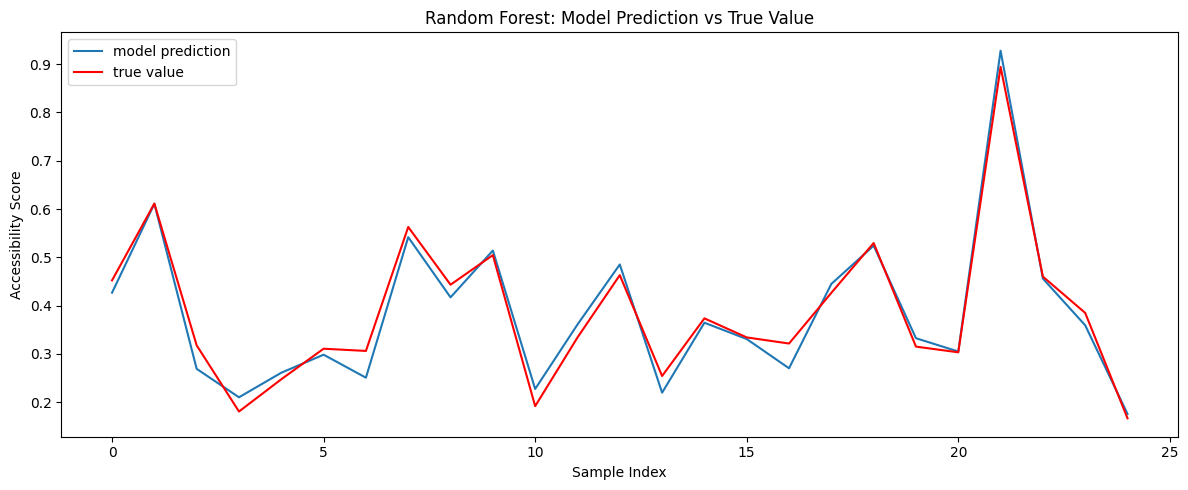

In [ ]:
import matplotlib.pyplot as plt
from builtins import min as py_min

# Convert predictions to pandas for plotting
predictions_pd = predictions.select("accessibility_score", "prediction").toPandas()

# Get first 50 samples (or all if less than 50)
n_samples = py_min(50, len(predictions_pd))

plt.figure(figsize=(12, 5))
plt.plot(range(n_samples), predictions_pd['prediction'][:n_samples], label='model prediction')
plt.plot(range(n_samples), predictions_pd['accessibility_score'][:n_samples], 'r', label='true value')
plt.xlabel('Sample Index')
plt.ylabel('Accessibility Score')
plt.title('Random Forest: Model Prediction vs True Value')
plt.legend()
plt.tight_layout()
plt.show()

### Scatter Plot - Prediction vs True Labels
Scatter plot showing predicted vs actual accessibility scores. Points close to the diagonal line indicate accurate predictions.

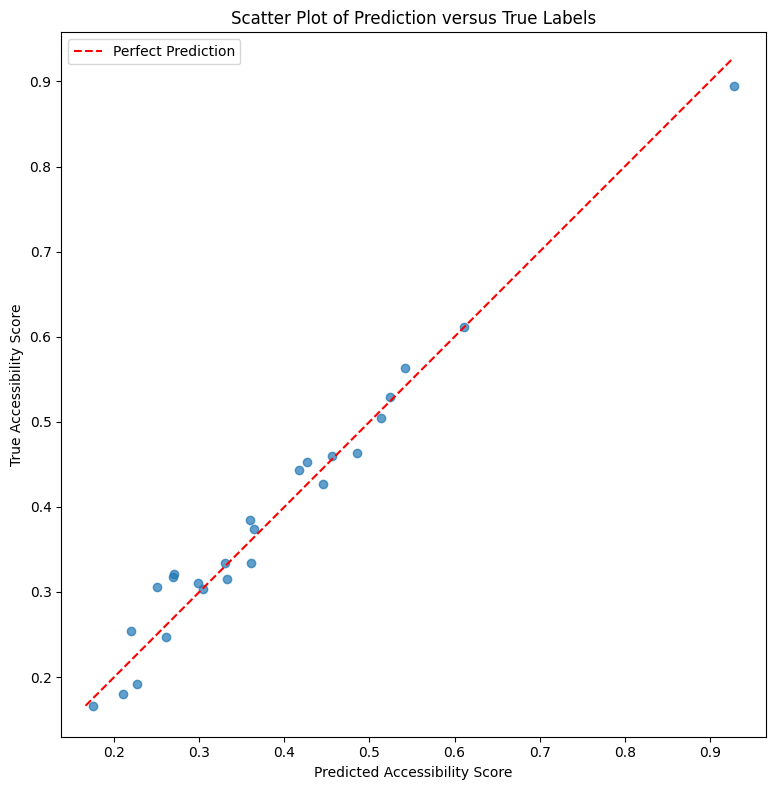

In [ ]:
from builtins import min as py_min, max as py_max

plt.figure(figsize=(8, 8))
plt.scatter(predictions_pd['prediction'], predictions_pd['accessibility_score'], alpha=0.7)
plt.xlabel('Predicted Accessibility Score')
plt.ylabel('True Accessibility Score')
plt.title('Scatter Plot of Prediction versus True Labels')
plt.axis('square')

# Add diagonal reference line (perfect prediction line)
min_val = py_min(predictions_pd['prediction'].min(), predictions_pd['accessibility_score'].min())
max_val = py_max(predictions_pd['prediction'].max(), predictions_pd['accessibility_score'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.legend()
plt.tight_layout()
plt.show()

### GBT Model - Prediction vs True Value Plots
Same visualizations for the Gradient Boosted Trees model to compare performance with Random Forest.

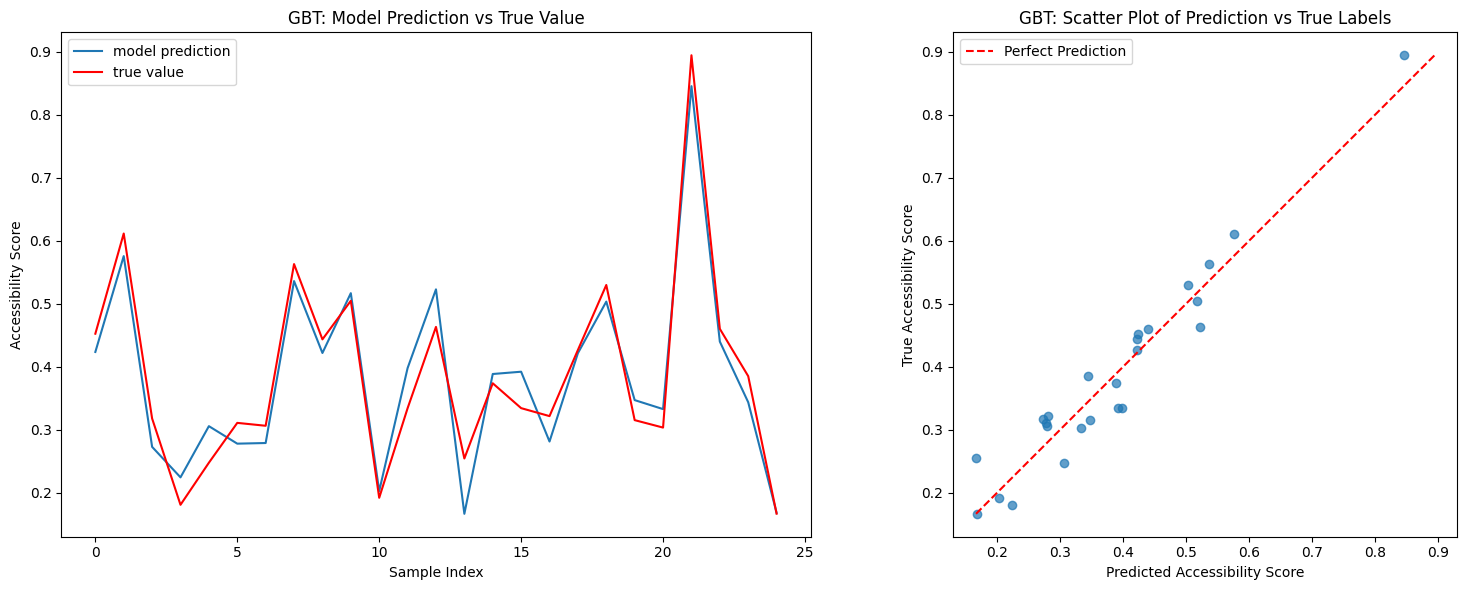

In [ ]:
# GBT Model Predictions
gbt_predictions_pd = gbt_predictions.select("accessibility_score", "prediction").toPandas()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Line plot - Prediction vs True Value
n_samples = py_min(50, len(gbt_predictions_pd))
axes[0].plot(range(n_samples), gbt_predictions_pd['prediction'][:n_samples], label='model prediction')
axes[0].plot(range(n_samples), gbt_predictions_pd['accessibility_score'][:n_samples], 'r', label='true value')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Accessibility Score')
axes[0].set_title('GBT: Model Prediction vs True Value')
axes[0].legend()

# Plot 2: Scatter plot - Prediction vs True Labels
axes[1].scatter(gbt_predictions_pd['prediction'], gbt_predictions_pd['accessibility_score'], alpha=0.7)
axes[1].set_xlabel('Predicted Accessibility Score')
axes[1].set_ylabel('True Accessibility Score')
axes[1].set_title('GBT: Scatter Plot of Prediction vs True Labels')
axes[1].set_aspect('equal')

# Add diagonal reference line
min_val = py_min(gbt_predictions_pd['prediction'].min(), gbt_predictions_pd['accessibility_score'].min())
max_val = py_max(gbt_predictions_pd['prediction'].max(), gbt_predictions_pd['accessibility_score'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Part 6: Visualization

### Accessibility Score Choropleth Map
Create an interactive map showing accessibility scores by neighborhood using color gradients (red = low accessibility, green = high accessibility).

In [ ]:
import folium
from folium.plugins import HeatMap
import json

# Convert final results to Pandas for visualization
results_pd = final_features_scored.toPandas()

# Create base map centered on Philadelphia
philly_map = folium.Map(location=[39.9526, -75.1652], zoom_start=11)

# Load neighborhoods GeoJSON
with open('philadelphia_neighborhoods.geojson', 'r') as f:
    neighborhoods_geojson = json.load(f)

# Check what properties are available in the GeoJSON
print("Available properties in GeoJSON:")
print(neighborhoods_geojson['features'][0]['properties'].keys())

# Find the correct property name for neighborhood
sample_props = neighborhoods_geojson['features'][0]['properties']
print("\nSample properties:", sample_props)

# Determine the correct key_on value
possible_keys = ['name', 'NAME', 'MAPNAME', 'mapname', 'listname', 'LISTNAME', 'neighborhood']
key_on_field = None
for key in possible_keys:
    if key in sample_props:
        key_on_field = f'feature.properties.{key}'
        print(f"\nUsing key_on: {key_on_field}")
        break

if key_on_field is None:
    print("Could not find name field. Available keys:", list(sample_props.keys()))
    # Use the first string field as fallback
    for k, v in sample_props.items():
        if isinstance(v, str):
            key_on_field = f'feature.properties.{k}'
            print(f"Using fallback key_on: {key_on_field}")
            break

# Add choropleth layer
folium.Choropleth(
    geo_data=neighborhoods_geojson,
    name='Accessibility Score',
    data=results_pd,
    columns=['neighborhood_name', 'accessibility_score'],
    key_on=key_on_field,
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Transit Accessibility Score',
    nan_fill_color='gray'
).add_to(philly_map)

folium.LayerControl().add_to(philly_map)

# Display map
philly_map

Available properties in GeoJSON:
dict_keys(['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area'])

Sample properties: {'NAME': 'BRIDESBURG', 'LISTNAME': 'Bridesburg', 'MAPNAME': 'Bridesburg', 'Shape_Leng': 27814.5465208, 'Shape_Area': 44586263.6032}

Using key_on: feature.properties.NAME


### Transit Stop Heatmap
Create a heatmap showing the density of transit stops across Philadelphia to visualize where transit service is concentrated.

In [ ]:
# Create heatmap of transit stops
stops_pd = all_stops.toPandas()

# Filter to valid coordinates
stops_pd = stops_pd.dropna(subset=['stop_lat', 'stop_lon'])

# Create heatmap
heatmap = folium.Map(location=[39.9526, -75.1652], zoom_start=11)

# Add heatmap layer
heat_data = [[row['stop_lat'], row['stop_lon']] for idx, row in stops_pd.iterrows()]
HeatMap(heat_data, radius=10, blur=15).add_to(heatmap)

# Add title
folium.map.Marker(
    [40.05, -75.16],
    icon=folium.DivIcon(
        html='<div style="font-size: 16pt; font-weight: bold;">SEPTA Transit Stop Density</div>'
    )
).add_to(heatmap)

heatmap

### Underserved Neighborhoods Bar Chart
Create a horizontal bar chart showing the top 15 most underserved neighborhoods ranked by accessibility score.

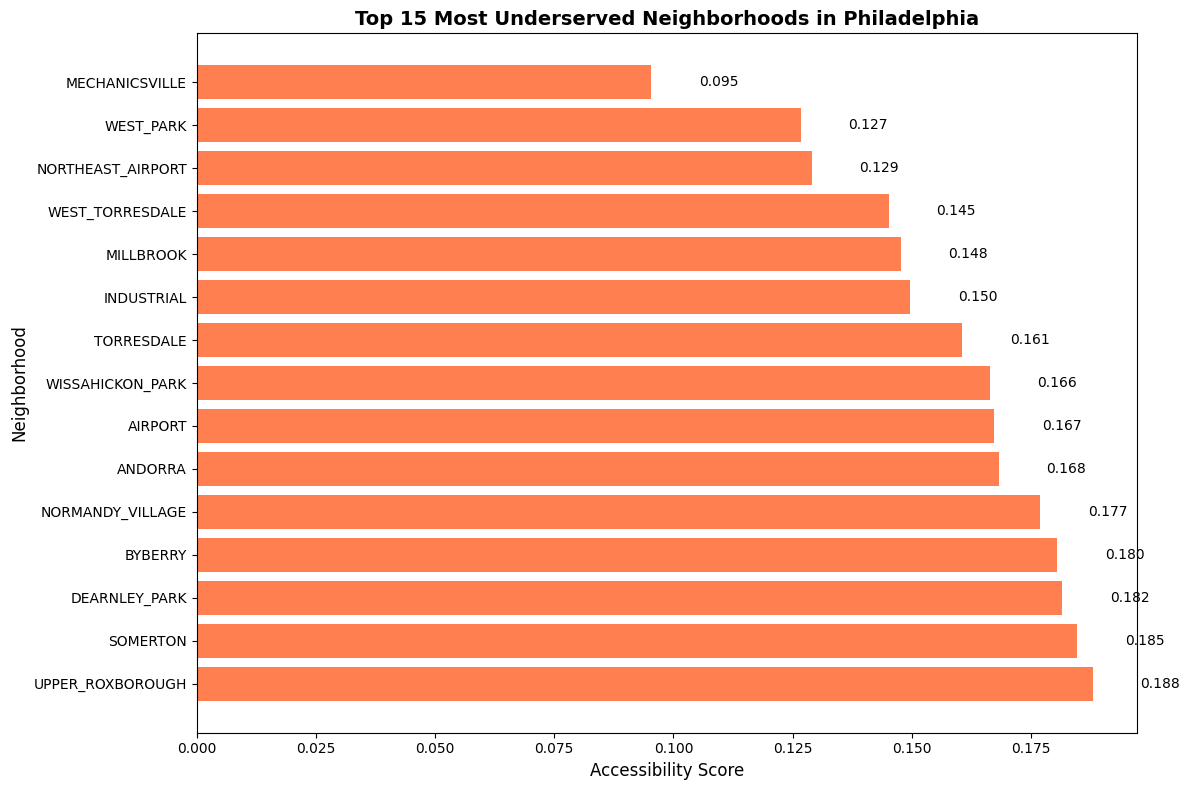

In [ ]:
import matplotlib.pyplot as plt

# Get top 15 underserved neighborhoods
underserved_pd = results_pd.nsmallest(15, 'accessibility_score')

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(underserved_pd['neighborhood_name'], underserved_pd['accessibility_score'], color='coral')
ax.set_xlabel('Accessibility Score', fontsize=12)
ax.set_ylabel('Neighborhood', fontsize=12)
ax.set_title('Top 15 Most Underserved Neighborhoods in Philadelphia', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, score in zip(bars, underserved_pd['accessibility_score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Feature Correlation Matrix
Create a heatmap showing correlations between features and the accessibility score to understand relationships between variables.

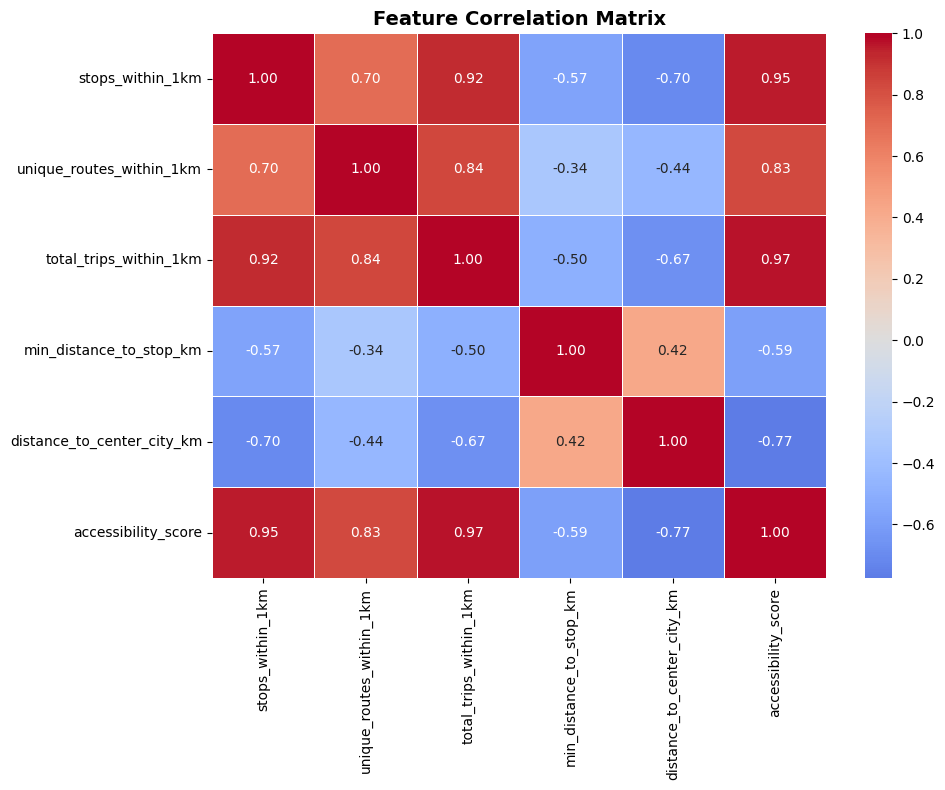

In [ ]:
import seaborn as sns

# Create correlation matrix
corr_cols = ['stops_within_1km', 'unique_routes_within_1km', 'total_trips_within_1km',
             'min_distance_to_stop_km', 'distance_to_center_city_km', 'accessibility_score']

corr_matrix = results_pd[corr_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Part 7: Summary and Results

### Summary Statistics
Display comprehensive summary of the analysis including data sizes, model performance metrics, and key findings (most/least underserved neighborhoods).

In [ ]:
# Use Python's built-in max/min by importing them explicitly
from builtins import max as py_max, min as py_min

# Print comprehensive summary
print("=" * 60)
print("SEPTA TRANSIT ACCESSIBILITY ANALYSIS - SUMMARY")
print("=" * 60)

print(f"\nDATA SUMMARY:")
print(f"   Total Transit Stops: {all_stops.count():,}")
print(f"   - Bus Stops: {bus_stops.count():,}")
print(f"   - Rail Stations: {rail_stops.count():,}")
print(f"   Total Bus Routes: {bus_routes.count()}")
print(f"   Total Rail Lines: {rail_routes.count()}")
print(f"   Neighborhoods Analyzed: {final_features_scored.count()}")

print(f"\nMODEL PERFORMANCE:")
print(f"   Best Model: {'GBT' if gbt_r2 > r2 else 'Random Forest'}")
print(f"   R-squared: {py_max(r2, gbt_r2):.4f}")
print(f"   RMSE: {py_min(rmse, gbt_rmse):.4f}")

print(f"\nKEY FINDINGS:")
print(f"   Most Underserved: {results_pd.nsmallest(1, 'accessibility_score')['neighborhood_name'].values[0]}")
print(f"   Best Served: {results_pd.nlargest(1, 'accessibility_score')['neighborhood_name'].values[0]}")
print(f"   Avg Accessibility Score: {results_pd['accessibility_score'].mean():.4f}")
print(f"   Score Std Dev: {results_pd['accessibility_score'].std():.4f}")

print("\n" + "=" * 60)

SEPTA TRANSIT ACCESSIBILITY ANALYSIS - SUMMARY

DATA SUMMARY:
   Total Transit Stops: 13,927
   - Bus Stops: 13,771
   - Rail Stations: 156
   Total Bus Routes: 172
   Total Rail Lines: 13
   Neighborhoods Analyzed: 159

MODEL PERFORMANCE:
   Best Model: Random Forest
   R-squared: 0.9708
   RMSE: 0.0264

KEY FINDINGS:
   Most Underserved: MECHANICSVILLE
   Best Served: WASHINGTON_SQUARE
   Avg Accessibility Score: 0.4026
   Score Std Dev: 0.1666



**Overall Results Summary:**

- We analyzed all 13,855 SEPTA transit stops (13,699 bus + 156 rail) across 159 Philadelphia neighborhoods.
- Neighborhoods near Center City (like Washington Square, Rittenhouse, and Center City) have the best transit access with 200+ stops within 1km, while outlying areas like Mechanicsville have very few stops nearby.
- Our Random Forest model can predict a neighborhood's transit accessibility with 97% accuracy (R-squared = 0.9711), meaning the 10 features we engineered capture almost all the variation in transit access.
- The most important factors driving accessibility are the number of stops and trips within 1km, followed by route diversity — essentially, having more frequent service from more routes matters most.
- These findings can help SEPTA and city planners identify "transit deserts" and prioritize where to add new routes or increase service frequency.

### Save Results
Export the accessibility results and model predictions to CSV files for further analysis or reporting.

In [ ]:
# Save results to CSV
results_pd.to_csv('accessibility_results.csv', index=False)

# Save model predictions
predictions.select("neighborhood_name", "accessibility_score", "prediction").toPandas().to_csv('model_predictions.csv', index=False)

print("Results saved to:")
print("  - accessibility_results.csv")
print("  - model_predictions.csv")

Results saved to:
  - accessibility_results.csv
  - model_predictions.csv
